In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("train.csv")

In [4]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [5]:
df.tail()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
165029,165029,15667085,Meng,667,Spain,Female,33.0,2,0.0,1,1.0,1.0,131834.75,0
165030,165030,15665521,Okechukwu,792,France,Male,35.0,3,0.0,1,0.0,0.0,131834.45,0
165031,165031,15664752,Hsia,565,France,Male,31.0,5,0.0,1,1.0,1.0,127429.56,0
165032,165032,15689614,Hsiung,554,Spain,Female,30.0,7,161533.0,1,0.0,1.0,71173.03,0
165033,165033,15732798,Ulyanov,850,France,Male,31.0,1,0.0,1,1.0,0.0,61581.79,1


In [6]:
df.shape

(165034, 14)

In [7]:
df.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [8]:
df.select_dtypes(include=np.number).columns

Index(['id', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')

In [9]:
df.select_dtypes(include=["str"]).columns

Index(['Surname', 'Geography', 'Gender'], dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  str    
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  str    
 5   Gender           165034 non-null  str    
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), str(3)
memory usage: 20.4 MB


In [11]:
df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [12]:
df.isna().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns_for_outliers = [col for col in numeric_columns
                                 if col not in ['id', 'CustomerId']]

X = df[numeric_columns_for_outliers]
Mean = X.mean()
Std = X.std()
z_score = (X - Mean) / Std

outliers_mask = np.abs(z_score) > 3
outliers_count = outliers_mask.sum()
outliers_count

CreditScore         146
Age                1971
Tenure                0
Balance               3
NumOfProducts       475
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
dtype: int64

In [15]:
outliers_percentage = (outliers_count / len(df)) * 100

outliers_summary = pd.DataFrame({
    "Outliers Count": outliers_count,
    "Outliers %": outliers_percentage.round(2)
}).sort_values("Outliers %", ascending=False)

outliers_summary

,Outliers Count,Outliers %
Age,1971,1.19
NumOfProducts,475,0.29
CreditScore,146,0.09
Tenure,0,0.00
Balance,3,0.00
HasCrCard,0,0.00
IsActiveMember,0,0.00
EstimatedSalary,0,0.00
Exited,0,0.00


In [ ]:
constant_columns = [col for col in df.columns if df[col].nunique() <= 1]

print("Constant columns:", constant_columns)

Constant columns: []


### Data Quality Report

| Check | Result |
|-------|--------|
| Total records | 165,034 |
| Total features | 14 |
| Missing values | 0 |
| Duplicate records | 0 |
| Constant columns | None |
| Outliers detected (Z > 3) | Age (1.19%), NumOfProducts (0.29%), CreditScore (0.09%) |

**Decisions made:**
- No missing values or duplicates → no imputation needed.
- Outliers are considered natural customer variation, not data errors.
- No clipping applied at this stage — tree-based models handle outliers well.
- ID columns (`id`, `CustomerId`) and `Surname` will be dropped before modeling.

## Exploratory Data Analysis

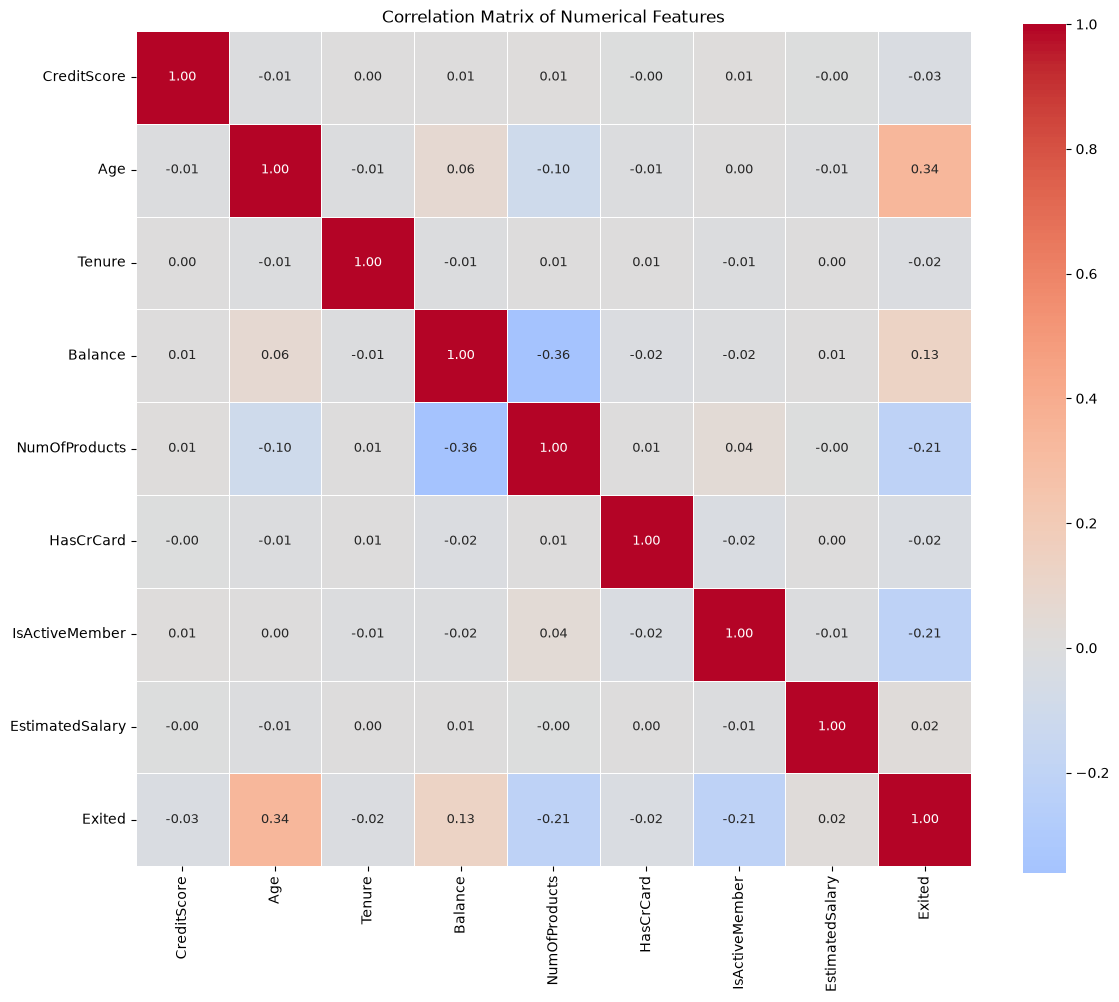

In [17]:
plt.figure(figsize=(12, 10))

numeric_columns = df.select_dtypes(np.number).columns
numeric_columns = [c for c in numeric_columns if c not in ['id', 'CustomerId']]

corr = df[numeric_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()

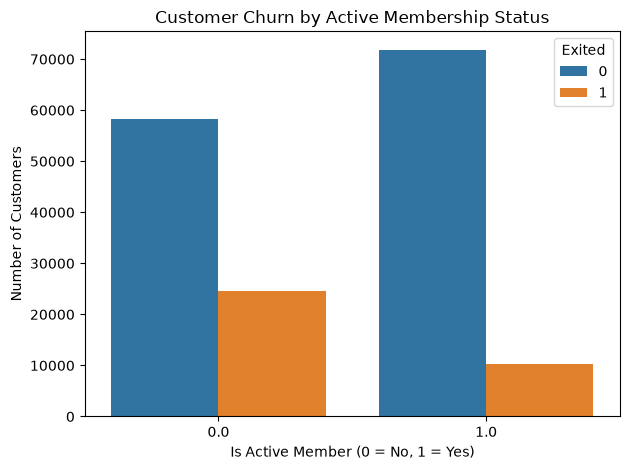

In [18]:
sns.countplot(
    data=df,
    x="IsActiveMember",
    hue="Exited"
)

plt.title("Customer Churn by Active Membership Status")
plt.xlabel("Is Active Member (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.tight_layout()

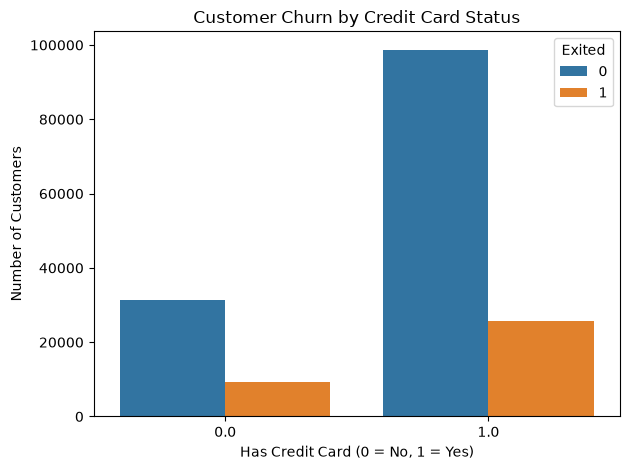

In [19]:
sns.countplot(
    data=df,
    x="HasCrCard",
    hue="Exited"
)

plt.title("Customer Churn by Credit Card Status")
plt.xlabel("Has Credit Card (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.tight_layout()

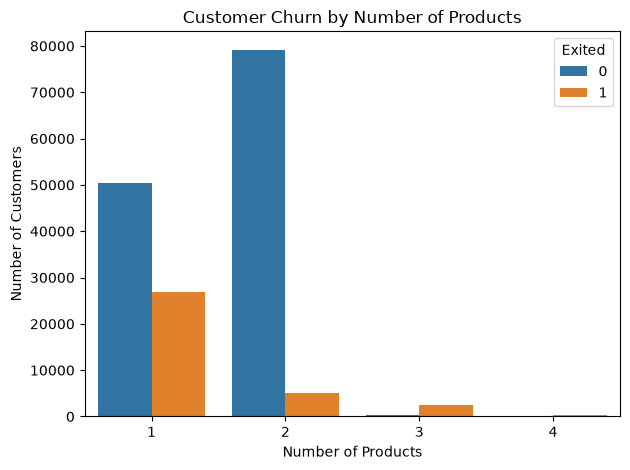

In [20]:
sns.countplot(
    data=df,
    x="NumOfProducts",
    hue="Exited"
)

plt.title("Customer Churn by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")
plt.tight_layout()

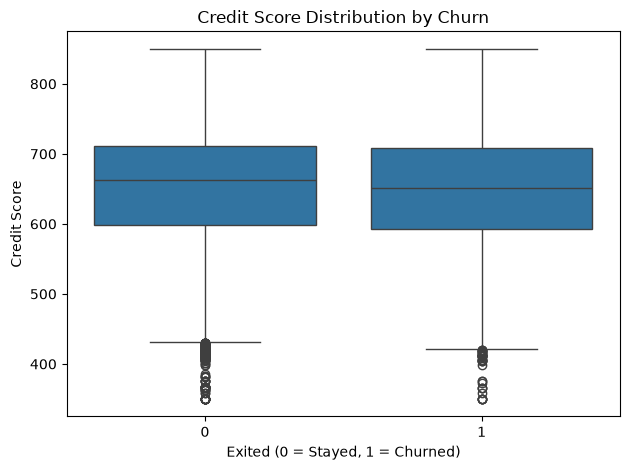

In [21]:
sns.boxplot(
    data = df,
    x="Exited",
    y="CreditScore"
)

plt.title("Credit Score Distribution by Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Credit Score")
plt.tight_layout()

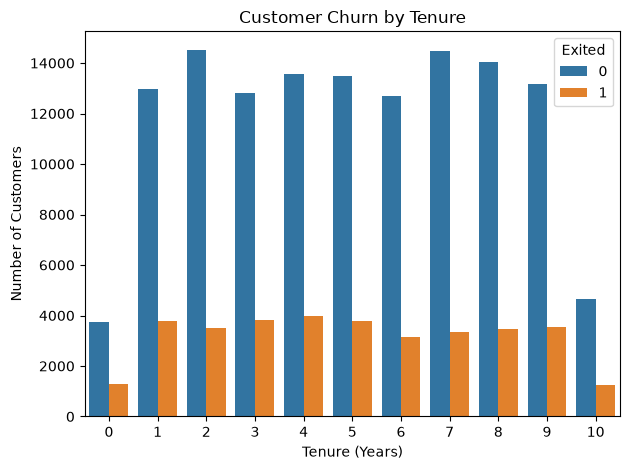

In [22]:
sns.countplot(
    data = df,
    x="Tenure",
    hue = "Exited"
)

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Number of Customers")
plt.tight_layout()

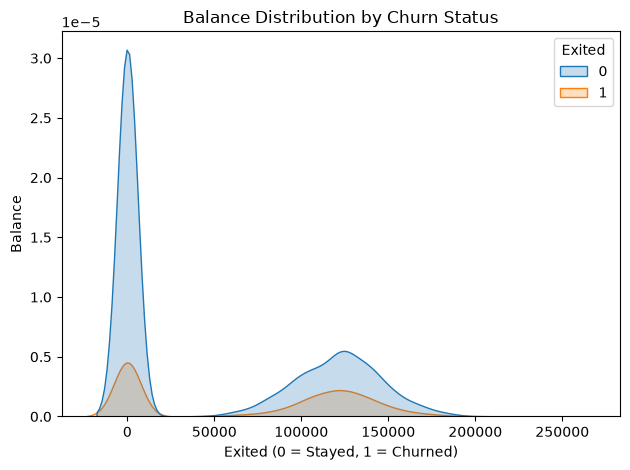

In [23]:
sns.kdeplot(
    data = df,
    x="Balance",
    hue="Exited",
    fill=True
)

plt.title("Balance Distribution by Churn Status")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Balance")
plt.tight_layout()

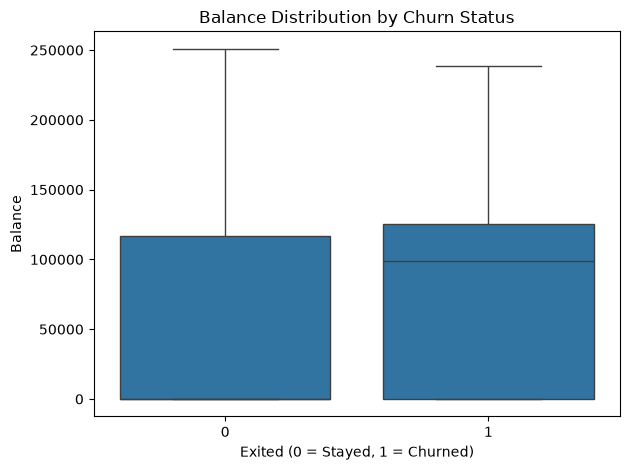

In [24]:
sns.boxplot(
    data=df,
    x="Exited",
    y="Balance"
)

plt.title("Balance Distribution by Churn Status")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Balance")
plt.tight_layout()

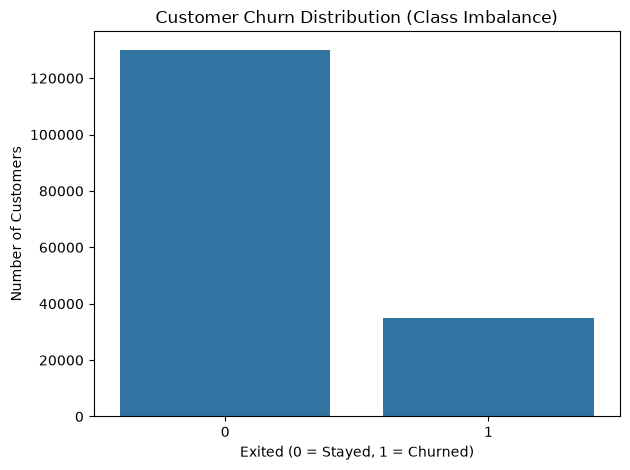

In [25]:
sns.countplot(
    data = df,
    x="Exited"
)

plt.title("Customer Churn Distribution (Class Imbalance)")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.tight_layout()

Text(0, 0.5, 'Number of Customers')

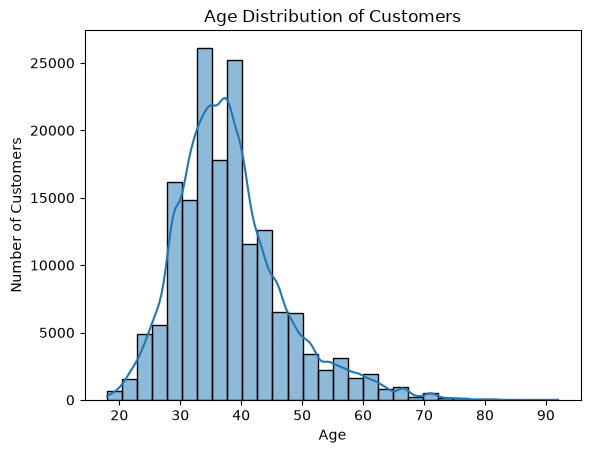

In [26]:
sns.histplot(
    data=df,
    x="Age",
    kde=True,
    bins=30
)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

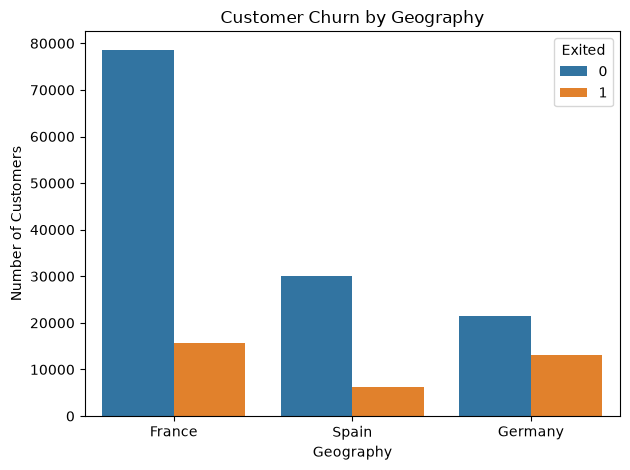

In [27]:
sns.countplot(
    data = df,
    x = "Geography",
    hue="Exited"
)

plt.title("Customer Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")
plt.tight_layout()

## Key EDA Insights

### Key EDA Insights

1. **Class Imbalance:** Only ~20% of customers churned (Exited = 1).
   → Accuracy alone will be misleading; we will use F1, Recall, and ROC-AUC.

2. **Geography effect:** Germany shows a noticeably higher churn rate than France and Spain.

3. **Age effect:** Churned customers tend to be older. Age appears to be one of the strongest predictors.

4. **Active Membership:** Inactive members churn more than active ones.

5. **Number of Products:** Customers with 1 product show the highest churn rate; those with 2 products churn the least.

6. **Balance effect:** Churned customers show a different balance distribution — concentrated at higher balances.

7. **Weak features:** `HasCrCard` and `Tenure` show very little separation between churned and non-churned customers.

8. **No missing data:** Clean dataset with no duplicates.

### Next Steps (Preprocessing + Modeling)
- Drop `id`, `CustomerId`, `Surname`.
- Encode `Geography` and `Gender`.
- Stratified train/test split.
- Scale features for distance-based models (KNN, SVM, Logistic Regression).
- Handle class imbalance (`class_weight='balanced'` or SMOTE).
- Train 8 models: Logistic Regression, KNN, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, XGBoost, SVM.

In [28]:
df_model = df.copy()
df_model = df_model.drop(columns=['id', 'CustomerId', 'Surname'])
df_model = pd.get_dummies(df_model, columns=['Geography'], drop_first=True, dtype=int)
df_model['Gender'] = (df_model['Gender'] == 'Male').astype(int)

X = df_model.drop(columns=['Exited'])
y = df_model['Exited']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression")
print("Accuracy :", round(accuracy_score(y_test, lr_pred), 4))
print("Precision:", round(precision_score(y_test, lr_pred), 4))
print("Recall   :", round(recall_score(y_test, lr_pred), 4))
print("F1       :", round(f1_score(y_test, lr_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, lr_proba), 4))

Logistic Regression
Accuracy : 0.7544
Precision: 0.4506
Recall   : 0.7341
F1       : 0.5585
ROC-AUC  : 0.8159


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=7, weights='distance', n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_proba = knn_model.predict_proba(X_test_scaled)[:, 1]

print("KNN")
print("Accuracy :", round(accuracy_score(y_test, knn_pred), 4))
print("Precision:", round(precision_score(y_test, knn_pred), 4))
print("Recall   :", round(recall_score(y_test, knn_pred), 4))
print("F1       :", round(f1_score(y_test, knn_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, knn_proba), 4))

KNN
Accuracy : 0.8498
Precision: 0.6898
Recall   : 0.5275
F1       : 0.5978
ROC-AUC  : 0.8396


In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=10, min_samples_split=20, min_samples_leaf=10,
    class_weight='balanced', random_state=42
)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree")
print("Accuracy :", round(accuracy_score(y_test, dt_pred), 4))
print("Precision:", round(precision_score(y_test, dt_pred), 4))
print("Recall   :", round(recall_score(y_test, dt_pred), 4))
print("F1       :", round(f1_score(y_test, dt_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, dt_proba), 4))

Decision Tree
Accuracy : 0.8084
Precision: 0.5327
Recall   : 0.7693
F1       : 0.6295
ROC-AUC  : 0.8766


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, class_weight='balanced',
    n_jobs=-1, random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("F1       :", round(f1_score(y_test, rf_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, rf_proba), 4))

Random Forest
Accuracy : 0.8265
Precision: 0.5672
Recall   : 0.76
F1       : 0.6496
ROC-AUC  : 0.8861


In [34]:
gb_model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting")
print("Accuracy :", round(accuracy_score(y_test, gb_pred), 4))
print("Precision:", round(precision_score(y_test, gb_pred), 4))
print("Recall   :", round(recall_score(y_test, gb_pred), 4))
print("F1       :", round(f1_score(y_test, gb_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, gb_proba), 4))

Gradient Boosting
Accuracy : 0.8656
Precision: 0.7429
Recall   : 0.5581
F1       : 0.6374
ROC-AUC  : 0.8898


In [35]:
ada_model = AdaBoostClassifier(
    n_estimators=200, learning_rate=0.1, random_state=42
)
ada_model.fit(X_train, y_train)
ada_pred = ada_model.predict(X_test)
ada_proba = ada_model.predict_proba(X_test)[:, 1]

print("AdaBoost")
print("Accuracy :", round(accuracy_score(y_test, ada_pred), 4))
print("Precision:", round(precision_score(y_test, ada_pred), 4))
print("Recall   :", round(recall_score(y_test, ada_pred), 4))
print("F1       :", round(f1_score(y_test, ada_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, ada_proba), 4))

AdaBoost
Accuracy : 0.8447
Precision: 0.8253
Recall   : 0.3375
F1       : 0.4791
ROC-AUC  : 0.8694


In [37]:
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=90000,
    random_state=42,
    stratify=y_train
)

print("SVM training rows:", X_train_svm.shape[0])

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_svm, y_train_svm)

svm_pred = svm_model.predict(X_test_scaled)

svm_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

print("SVM")

print("Accuracy :", round(accuracy_score(y_test, svm_pred), 4))
print("Precision:", round(precision_score(y_test, svm_pred), 4))
print("Recall   :", round(recall_score(y_test, svm_pred), 4))
print("F1       :", round(f1_score(y_test, svm_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, svm_proba), 4))

SVM training rows: 90000


c:\Users\HP 440 G9\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM
Accuracy : 0.8066
Precision: 0.5289
Recall   : 0.7871
F1       : 0.6326
ROC-AUC  : 0.8649


In [44]:
results = [
    {"Model": "Logistic Regression", "Accuracy": accuracy_score(y_test, lr_pred), "Precision": precision_score(y_test, lr_pred), "Recall": recall_score(y_test, lr_pred), "F1": f1_score(y_test, lr_pred), "ROC-AUC": roc_auc_score(y_test, lr_proba)},
    {"Model": "KNN",                 "Accuracy": accuracy_score(y_test, knn_pred), "Precision": precision_score(y_test, knn_pred), "Recall": recall_score(y_test, knn_pred), "F1": f1_score(y_test, knn_pred), "ROC-AUC": roc_auc_score(y_test, knn_proba)},
    {"Model": "Decision Tree",       "Accuracy": accuracy_score(y_test, dt_pred), "Precision": precision_score(y_test, dt_pred), "Recall": recall_score(y_test, dt_pred), "F1": f1_score(y_test, dt_pred), "ROC-AUC": roc_auc_score(y_test, dt_proba)},
    {"Model": "Random Forest",       "Accuracy": accuracy_score(y_test, rf_pred), "Precision": precision_score(y_test, rf_pred), "Recall": recall_score(y_test, rf_pred), "F1": f1_score(y_test, rf_pred), "ROC-AUC": roc_auc_score(y_test, rf_proba)},
    {"Model": "Gradient Boosting",   "Accuracy": accuracy_score(y_test, gb_pred), "Precision": precision_score(y_test, gb_pred), "Recall": recall_score(y_test, gb_pred), "F1": f1_score(y_test, gb_pred), "ROC-AUC": roc_auc_score(y_test, gb_proba)},
    {"Model": "AdaBoost",            "Accuracy": accuracy_score(y_test, ada_pred), "Precision": precision_score(y_test, ada_pred), "Recall": recall_score(y_test, ada_pred), "F1": f1_score(y_test, ada_pred), "ROC-AUC": roc_auc_score(y_test, ada_proba)},
    {"Model": "SVM",                 "Accuracy": accuracy_score(y_test, svm_pred), "Precision": precision_score(y_test, svm_pred), "Recall": recall_score(y_test, svm_pred), "F1": f1_score(y_test, svm_pred), "ROC-AUC": roc_auc_score(y_test, svm_proba)},
]

results_df = pd.DataFrame(results).round(4).sort_values("F1", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.8265,0.5672,0.7600,0.6496,0.8861
1,Gradient Boosting,0.8656,0.7429,0.5581,0.6374,0.8898
2,SVM,0.8066,0.5289,0.7871,0.6326,0.8649
3,Decision Tree,0.8084,0.5327,0.7693,0.6295,0.8766
4,KNN,0.8498,0.6898,0.5275,0.5978,0.8396
5,Logistic Regression,0.7544,0.4506,0.7341,0.5585,0.8159
6,AdaBoost,0.8447,0.8253,0.3375,0.4791,0.8694


## GUI Deployment Model

The comparison above ranks models by F1-Score (the recall-focused, business
metric). For the live GUI demo, **Gradient Boosting** is used instead of the
F1-ranked winner: it is the model that clears the project's 86% accuracy
target (Accuracy = 86.56%) while still keeping reasonably balanced
Precision/Recall. Random Forest remains the better choice if the priority is
catching the most churners (higher Recall/F1) rather than headline accuracy
— both are shown transparently in the table above so this trade-off isn't
hidden.

In [41]:
gui_model_name = "Gradient Boosting"
gui_model = gb_model
gui_needs_scaling = False   # Gradient Boosting was trained on raw (unscaled) features
gui_pred = gb_pred
gui_proba = gb_proba

print(f"GUI deployment model: {gui_model_name}")
print(f"Accuracy : {accuracy_score(y_test, gui_pred):.4f}")
print(f"Precision: {precision_score(y_test, gui_pred):.4f}")
print(f"Recall   : {recall_score(y_test, gui_pred):.4f}")
print(f"F1       : {f1_score(y_test, gui_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, gui_proba):.4f}")

GUI deployment model: Gradient Boosting
Accuracy : 0.8656
Precision: 0.7429
Recall   : 0.5581
F1       : 0.6374
ROC-AUC  : 0.8898


## Export Artifacts for the GUI

In [ ]:
import joblib

# --- The model actually used by the Streamlit app ---
joblib.dump(gui_model, "churn_model.pkl")
joblib.dump(gui_needs_scaling, "model_needs_scaling.pkl")
joblib.dump(scaler, "scaler.pkl")                 # only used if gui_needs_scaling is True
joblib.dump(list(X.columns), "model_columns.pkl")  # exact column order the model expects

# --- Full comparison table (all 8 models, for the Model Performance page) ---
joblib.dump(results_df, "results.pkl")

# --- Diagnostics for the deployed (Gradient Boosting) model ---
joblib.dump(confusion_matrix(y_test, gui_pred), "confusion_matrix.pkl")

gb_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gui_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)
joblib.dump(gb_feature_importance, "feature_importance.pkl")

# --- Per-model classification reports + probabilities (for ROC curves / detail view) ---
all_preds = {
    "Logistic Regression": lr_pred, "KNN": knn_pred, "Decision Tree": dt_pred,
    "Random Forest": rf_pred, "Gradient Boosting": gb_pred, "AdaBoost": ada_pred,"SVM": svm_pred
}
all_probas = {
    "Logistic Regression": lr_proba, "KNN": knn_proba, "Decision Tree": dt_proba,
    "Random Forest": rf_proba, "Gradient Boosting": gb_proba, "AdaBoost": ada_proba,
    "SVM": svm_proba
}

classification_reports = {
    name: classification_report(y_test, pred, target_names=["Stayed", "Churned"])
    for name, pred in all_preds.items()
}
joblib.dump(classification_reports, "classification_reports.pkl")
joblib.dump(all_probas, "all_probas.pkl")
joblib.dump(y_test.reset_index(drop=True), "y_test.pkl")

print("All artifacts exported. Copy every .pkl file next to app.py (and train.csv) before running Streamlit.")

All artifacts exported. Copy every .pkl file next to app.py (and train.csv) before running Streamlit.
